# Example 02 - Polynomial compressors and plate heat Exchangers

This notebook builds a complete refrigeration cycle from the two component models of the
toolbox:

1. A `PolynomialCompressor` parametrised with a 10 coefficient EN12900 / AHRI540 compressor map
2. Two `PlateHeatExchanger`, one as condenser and one as evaporator, sized for the duty of that compressor
3. Evaluating the cycle and plotting it in a log(p)h- and a Ts-diagram

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from CoolProp.CoolProp import AbstractState

from refrigerationtoolbox.cycle.Compressor import celsius_to_kelvin_coeffs
from refrigerationtoolbox.cycle.Cycle import Cycle
from refrigerationtoolbox.cycle.PlateHeatExchanger import PlateHeatExchanger
from refrigerationtoolbox.cycle.PolynomialCompressor import PolynomialCompressor
from refrigerationtoolbox.plotter.CyclePlotter import CyclePlotter

## 1. Operating point and boundary conditions

The cycle runs with R134a between an evaporating temperature of 0 °C and a condensing temperature
of 30 °C, with 5 K of superheat at the compressor inlet and 5 K of subcooling at the condenser
outlet. Water is used on both secondary loops.

`Te` and `Tc` are inputs here, they are not solved for. Both plate heat exchangers are sized in
section 3 so that they can actually transfer the resulting duty at these two temperatures.

In [26]:
Te = 0 + 273.15  # [K] evaporation temperature on the low pressure side
Tc = 30 + 273.15  # [K] condensation temperature on the high pressure side
sh = 5  # [K] superheating at compressor inlet
sc = 0  # [K] subcooling at condensor outlet

# Refrigerant used in the refrigeration cycle
fluid_ref = AbstractState("HEOS", "R134a")

# using water in the secondary cycles of the evaporators and condensers
fluid_sec_cond = AbstractState("HEOS", "Water")
fluid_sec_evap = AbstractState("HEOS", "Water")

# Boundary condition at heat exchangers
m_flow_sec_cond = 2.0  # [kg/s] Mass flow rate at the inlet of the secondary cycle of the condenser
p_sec_cond = 1e5  # [Pa] Pressure in the secondary cycle of the condenser
T_sec_in_cond = 20 + 273.15  # [K] Temperature at the inlet of the secondary cycle of the condenser
m_flow_sec_evap = 2.0  # [kg/s] Mass flow rate at the inlet of the secondary cycle of the evaporator
p_sec_evap = 1e5  # [Pa] Pressure in the secondary cycle of the evaporator
T_sec_in_evap = 10 + 273.15  # [K] Temperature at the inlet of the secondary cycle of the evaporator

## 2. The polynomial compressor

`PolynomialCompressor` does not model the compression itself. It evaluates three 10 coefficient
polynomials in the evaporating and the condensing temperature, one for the mass flow rate, one for
the cooling capacity and one for the electrical power draw:

$$y = a_1 + a_2 T_e + a_3 T_c + a_4 T_e^2 + a_5 T_e T_c + a_6 T_c^2 + a_7 T_e^3 + a_8 T_e^2 T_c
      + a_9 T_e T_c^2 + a_{10} T_c^3$$

Manufacturers publish these coefficients for temperatures in °C or K. The Polynomial used here is for Bitzer ESH730Y at $T_e=0°C$, $T_c=30°C$, $sh=5~K$ and $sc=0~K$. Bitzer assumes $T_e$ and $T_c$ to be in °C. `PolynomialCompressor` requires $T_e$ and $T_c$ to
be in K. The function `celsius_to_kelvin_coeffs` converts a polynomial compressor coefficient set to Kelvin. The mass flow coefficients are additionally divided by 3600 to convert the mass flow from kg/h to kg/s.

In [27]:
# m [kg/h] -> [kg/s]
m_flow_coeffs = celsius_to_kelvin_coeffs(
    np.array(
        [
            433.405599495116,
            14.9909912535786,
            -0.332858512339685,
            0.204623586153767,
            0.00783475919685306,
            -0.00550234077032464,
            0.00147385448738919,
            3.00018105510409e-05,
            -0.000180738817371161,
            -7.5930225497561e-07,
        ]
    )
    / 3600
)
# Q_ref [W]
Q_ref_coeffs = celsius_to_kelvin_coeffs(
    np.array(
        [
            24505.1298847642,
            923.573745214948,
            -189.016989612147,
            14.4708589480514,
            -5.40337736007146,
            -0.16360259809141,
            0.0859846535814322,
            -0.0908501243025993,
            -0.0171380876239127,
            -0.000200200163193361,
        ]
    )
)
# P [W]
P_coeffs = celsius_to_kelvin_coeffs(
    np.array(
        [
            2096.19728039823,
            15.1114673839915,
            33.2755840370894,
            -0.0533830987334415,
            -0.194300599703649,
            0.433409284725298,
            -0.00897303325535081,
            0.00530884169336271,
            1.52588234366472e-05,
            0.00607808111008199,
        ]
    )
)

poly_comp = PolynomialCompressor(
    fluid_ref,
    m_flow_coeffs=m_flow_coeffs,
    Q_ref_coeffs=Q_ref_coeffs,
    P_coeffs=P_coeffs,
)

# The compressor can be evaluated on its own, before it is part of a cycle
poly_comp.calc(Te, Tc, sh, sc)
print(poly_comp)

PolynomialCompressor [R134a] (m_flow = 0.12 kg/s, P = 3.65 kW)
  Inlet : T=278.15 K, p=292.80 kPa, h=403.07 kJ/kg, s=1.74 kJ/kgK, d=14.07 kg/m³
  Outlet: T=321.61 K, p=770.20 kPa, h=433.84 kJ/kg, s=1.78 kJ/kgK, d=33.77 kg/m³
  Q_heat=22.33 kW, Q_ref=18.68 kW


The main drawback of this approach is that the polynomial coefficients change for different values of $sh$ and $sc$.
Only changing $sh$ and $sc$ in `calc` without providing a new polynoial will lead to inaccurate results.

## 3. Plate heat exchangers
The `PlateHeatExchanger` is a bit more difficult to use. It requires the user to provide a geometry. The geometry has to be able
to provide adequate heat transfer for the given temperatures at the boundaries, mass flow through the heat exchanger and the heat capacity.
The criteria for the 

In the following we will determine the minimum number of plates required for a plate heat exchanger to be feasable.

In [28]:
# PateHeatExchanger Geometry
geom = {
    "number_of_passes": 1,
    "plate_thickness_m": 0.0007,  # [m] plate thickness
    "chevron_angle_rad": 1.0471975511965976,  # [rad] chevron angle
    "pitch": 0.0025,  # [m] pitch
    "plate_amplitude_m": 0.001,  # [m] plate amplitude in meters
    "corrugation_pitch_m": 0.007,  # [m] corrugation pitch
    "Dp": 0.05,  # [m] port diameter
    "Lp": 0.8,  # [m] plate length
    "Bp": 0.35,  # [m] plate width
    "Ntmin": 4,  # minimum number of plates
    "Ntmax": 150,  # maximum number of plates
    "Nt": 100,  # number of plates, will be overwritten if determine_min_n_plates is called
}


condenser = PlateHeatExchanger(fluid_ref, fluid_sec_cond, geom, dp_ref_max=4e4, dp_sec_max=4e4, dT_pinch=2)
evaporator = PlateHeatExchanger(fluid_ref, fluid_sec_evap, geom, dp_ref_max=4e4, dp_sec_max=4e4, dT_pinch=2)

# Cycle calculation is used to determine meaningful boundary conditions for the heat exchangers
# We are using Nt = 100 plates here
cycle = Cycle(fluid_ref, Te=Te, Tc=Tc, sh=sh, sc=sc)
cycle.set_compressor(poly_comp)
cycle.set_condenser(condenser)
cycle.set_evaporator(evaporator)

# First pass, only needed to get the refrigerant states and the mass flow rate for the sizing
cycle.calc(
    m_flow_sec_cond=m_flow_sec_cond,
    p_sec_cond=p_sec_cond,
    T_sec_in_cond=T_sec_in_cond,
    m_flow_sec_evap=m_flow_sec_evap,
    p_sec_evap=p_sec_evap,
    T_sec_in_evap=T_sec_in_evap,
)

# The condenser goes from state 2 to state 3, the evaporator from state 4 back to state 1
condenser.determine_min_n_plates(
    U0=2500,
    m_flow_ref=cycle.m_flow,
    m_flow_sec=m_flow_sec_cond,
    h_ref_in=cycle.h2,
    h_ref_out=cycle.h3,
    p_ref=cycle.pc,
    p_sec=p_sec_cond,
    T_sec_in=T_sec_in_cond,
)
evaporator.determine_min_n_plates(
    U0=2500,
    m_flow_ref=cycle.m_flow,
    m_flow_sec=m_flow_sec_evap,
    h_ref_in=cycle.h4,
    h_ref_out=cycle.h1,
    p_ref=cycle.pe,
    p_sec=p_sec_evap,
    T_sec_in=T_sec_in_evap,
)

print(f"Condenser  : {condenser.Nt} plates, feasible = {condenser.feas}")
print(f"Evaporator : {evaporator.Nt} plates, feasible = {evaporator.feas}")

Condenser  : 58 plates, feasible = True
Evaporator : 28 plates, feasible = True


## 4. Evaluating the cycle

With both heat exchangers sized, the cycle is evaluated again. `calc` now solves the 
heat exchangers at their final plate count.

In [29]:
cycle.calc(
    m_flow_sec_cond=m_flow_sec_cond,
    p_sec_cond=p_sec_cond,
    T_sec_in_cond=T_sec_in_cond,
    m_flow_sec_evap=m_flow_sec_evap,
    p_sec_evap=p_sec_evap,
    T_sec_in_evap=T_sec_in_evap,
)

print("--- Cycle states ---")
print(cycle)


print("\n--- Evaporator state ---")
print(cycle.evaporator)

--- Cycle states ---
Cycle (refrigerant=R134a, Te=273.15, Tc=303.15, sh=5, sc=0)
   Q_heat: 22.33 kW, Q_ref: 18.68 kW, P_comp: 3.65 kW, COP_heat=6.12, COP_cool= 5.12, m_flow=0.12 kg/s
   State 1: T=278.15, P=292.80 kPa, h=403.07 kJ/kg, s=1.74 kJ/(kgK), rho=14.07 kg/m³
   State 2: T=321.61, P=770.20 kPa, h=433.84 kJ/kg, s=1.78 kJ/(kgK), rho=33.77 kg/m³
   State 3: T=303.15, P=770.20 kPa, h=241.72 kJ/kg, s=1.14 kJ/(kgK), rho=1187.46 kg/m³
   State 4: T=273.15, P=292.80 kPa, h=242.35 kJ/kg, s=1.16 kJ/(kgK), rho=65.00 kg/m³

--- Evaporator state ---
PlateHeatExchanger (evap, Q = 18.68 kW)
  Refrigerant [R134a] (m_flow = 0.12 kg/s p=292.80 kPa):
    Inlet : T=273.15 K, h=242.35 kJ/kg, s=1.16 kJ/kgK, d=65.00 kg/m³
    Outlet: T=278.15 K, h=403.07 kJ/kg, s=1.74 kJ/kgKd=14.07 kg/m³
  Secondary fluid [Water] (m_flow = 2.00 kg/s, p=100.00 kPa):
    Inlet : T=283.15 K, h=42.12 kJ/kg, s=0.15 kJ/kgK, d=999.70 kg/m³
    Outlet: T=285.38 K, h=51.46 kJ/kg, s=0.18 kJ/kgK, d=999.47 kg/m³
 Feasable = Tru

In [30]:
print("--- Compressor state ---")
print(cycle.compressor)

--- Compressor state ---
PolynomialCompressor [R134a] (m_flow = 0.12 kg/s, P = 3.65 kW)
  Inlet : T=278.15 K, p=292.80 kPa, h=403.07 kJ/kg, s=1.74 kJ/kgK, d=14.07 kg/m³
  Outlet: T=321.61 K, p=770.20 kPa, h=433.84 kJ/kg, s=1.78 kJ/kgK, d=33.77 kg/m³
  Q_heat=22.33 kW, Q_ref=18.68 kW


In [31]:
print("--- Condenser state ---")
print(cycle.condenser)

--- Condenser state ---
PlateHeatExchanger (cond, Q = 22.33 kW)
  Refrigerant [R134a] (m_flow = 0.12 kg/s p=770.20 kPa):
    Inlet : T=321.61 K, h=433.84 kJ/kg, s=1.78 kJ/kgK, d=33.77 kg/m³
    Outlet: T=303.15 K, h=241.72 kJ/kg, s=1.14 kJ/kgKd=1187.46 kg/m³
  Secondary fluid [Water] (m_flow = 2.00 kg/s, p=100.00 kPa):
    Inlet : T=293.15 K, h=84.01 kJ/kg, s=0.30 kJ/kgK, d=998.21 kg/m³
    Outlet: T=295.82 K, h=95.17 kJ/kg, s=0.33 kJ/kgK, d=997.62 kg/m³
 Feasable = True, Nt = 58, dp_ref = 0.13 kPa, dp_sec = 9.22 kPa, self.dT_min = 7.60 K


In [32]:
print("--- Evaporator state ---")
print(cycle.evaporator)

--- Evaporator state ---
PlateHeatExchanger (evap, Q = 18.68 kW)
  Refrigerant [R134a] (m_flow = 0.12 kg/s p=292.80 kPa):
    Inlet : T=273.15 K, h=242.35 kJ/kg, s=1.16 kJ/kgK, d=65.00 kg/m³
    Outlet: T=278.15 K, h=403.07 kJ/kg, s=1.74 kJ/kgKd=14.07 kg/m³
  Secondary fluid [Water] (m_flow = 2.00 kg/s, p=100.00 kPa):
    Inlet : T=283.15 K, h=42.12 kJ/kg, s=0.15 kJ/kgK, d=999.70 kg/m³
    Outlet: T=285.38 K, h=51.46 kJ/kg, s=0.18 kJ/kgK, d=999.47 kg/m³
 Feasable = True, Nt = 28, dp_ref = 19.98 kPa, dp_sec = 38.34 kPa, self.dT_min = 5.00 K


## 5. Plotting the cycle

The cycle is plotted exactly as in example 01.

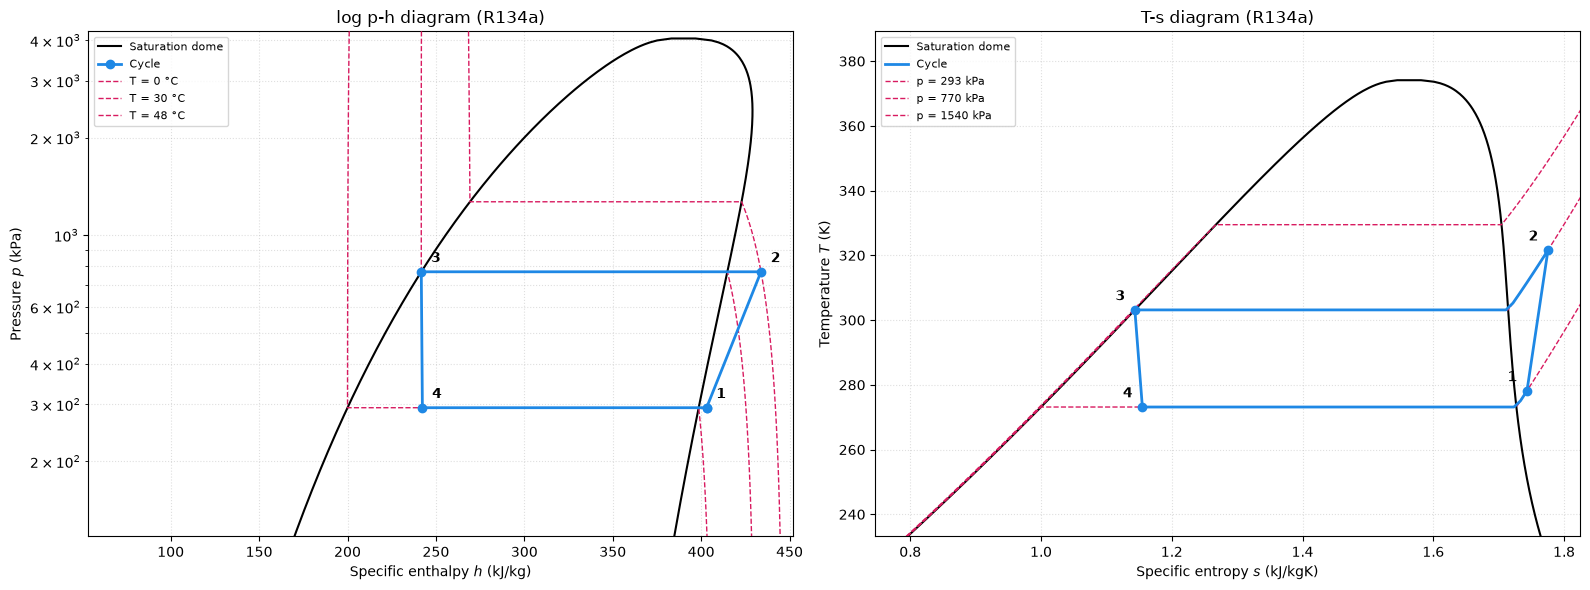

In [33]:
plotter = CyclePlotter()

fig, (ax_ph, ax_Ts) = plt.subplots(1, 2, figsize=(16, 6))

plotter.plot_ph(ax_ph, cycle)
plotter.plot_ts(ax_Ts, cycle)

fig.tight_layout()
plt.show()